In [1]:
# fusion 2 trial
!pip install -q mediapipe==0.10.14 opencv-python-headless librosa scikit-learn scipy matplotlib seaborn tensorflow

import os, cv2, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import librosa
import mediapipe as mp
import tensorflow as tf
from scipy.signal import resample, find_peaks
from scipy.stats import skew, kurtosis
from sklearn.metrics import confusion_matrix
from google.colab import files
warnings.filterwarnings('ignore')


SELECTED_JOINTS  = [11, 12, 13, 14, 15, 16, 23, 24, 25, 26, 27]
WINDOW_SIZE      = 30
THRESHOLD        = 0.82
STRIDE           = 5
COOLDOWN_FRAMES  = 180
MERGE_WINDOW_SEC = 0.75

LABELS       = ['Forehand', 'Backhand', 'Serve']
LABEL_MAP    = {0: 'Forehand', 1: 'Backhand', 2: 'Serve'}
LABEL_COLORS = {'Forehand': '#2E75B6', 'Backhand': '#FFB800', 'Serve': '#CC66FF'}
GT_MAP       = {'F': 0, 'B': 1, 'S': 2}

print(" Imports ready")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 18.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
 Imports ready


In [2]:

print("\n1. Upload tennis_cnn_lstm_v1.h5")
u1 = files.upload()
camera_model = tf.keras.models.load_model(list(u1.keys())[0])
print(f" Camera CNN-LSTM — input: {camera_model.input_shape}")

print("\n2. Upload Au8dio_svm.pkl")
u2 = files.upload()
with open(list(u2.keys())[0], 'rb') as f:
    audio_data = pickle.load(f)
svm_audio    = audio_data['svm']
scaler_audio = audio_data['scaler']
N_MFCC_AUDIO = audio_data['n_mfcc']
CLIP_AUDIO   = audio_data['clip_duration']
print(f" Audio SVM — n_mfcc={N_MFCC_AUDIO}, clip={CLIP_AUDIO}s")

print("\n3. Upload accel_cnn_lstm_v4.h5")
u3 = files.upload()
accel_cnn = tf.keras.models.load_model(list(u3.keys())[0])
print(f" Accel CNN-LSTM — input: {accel_cnn.input_shape}")

print("\n4. Upload accel_svm_v4.pkl")
u4 = files.upload()
with open(list(u4.keys())[0], 'rb') as f:
    svm_data = pickle.load(f)
svm_model  = svm_data['model']
svm_scaler = svm_data['scaler']
print(" Accel SVM loaded")



1. Upload tennis_cnn_lstm_v1.h5


Saving tennis_cnn_lstm_v1.h5 to tennis_cnn_lstm_v1.h5
 Camera CNN-LSTM — input: (None, 30, 22)

2. Upload Au8dio_svm.pkl


Saving Au8dio_svm.pkl to Au8dio_svm.pkl
 Audio SVM — n_mfcc=40, clip=0.5s

3. Upload accel_cnn_lstm_v4.h5


Saving accel_cnn_lstm_v4.h5 to accel_cnn_lstm_v4.h5
 Accel CNN-LSTM — input: (None, 60, 4)

4. Upload accel_svm_v4.pkl


Saving accel_svm_v4.pkl to accel_svm_v4.pkl
 Accel SVM loaded


In [3]:

print("\n5. Upload session1.mp4")
uv1 = files.upload(); V1_VIDEO = list(uv1.keys())[0]
print(f" {V1_VIDEO}")

print("\n6. Upload session2.mp4")
uv2 = files.upload(); V2_VIDEO = list(uv2.keys())[0]
print(f" {V2_VIDEO}")

print("\n7. Upload results_2.csv")
ua2 = files.upload(); V2_ACCEL = list(ua2.keys())[0]
print(f" {V2_ACCEL}")

print("\n8. Upload session3.mp4")
uv3 = files.upload(); V3_VIDEO = list(uv3.keys())[0]
print(f" {V3_VIDEO}")

print("\n9. Upload results_3.csv")
ua3 = files.upload(); V3_ACCEL = list(ua3.keys())[0]
print(f" {V3_ACCEL}")

print("\n All files uploaded")


5. Upload session1.mp4


Saving ss1.mp4 to ss1.mp4
 ss1.mp4

6. Upload session2.mp4


Saving ss2.mp4 to ss2.mp4
 ss2.mp4

7. Upload results_2.csv


Saving results 2.csv to results 2.csv
 results 2.csv

8. Upload session3.mp4


Saving ss3.mp4 to ss3.mp4
 ss3.mp4

9. Upload results_3.csv


Saving results 3.csv to results 3.csv
 results 3.csv

 All files uploaded


In [4]:



V1_GT = [GT_MAP[x] for x in ['S','S','B','F','F','B','F','S','F','S','F']]  # 11 shots
V2_GT = [GT_MAP[x] for x in ['S','F','S','F','F','B','S','S','B','F','F','B','F']]  # 13 shots
V3_GT = [GT_MAP[x] for x in ['S','F','B','F','F']]  # 5 shots

V2_ACCEL_OFFSET = 15.67
V3_ACCEL_OFFSET = 10.89


WHOOP = {'Avg HR': 147, 'Max HR': 178, 'Strain': 4.6, 'Calories': 23,
         'Zone1': 39, 'Zone2': 8, 'Zone3': 4, 'Zone4': 49, 'Zone5': 0}

print("Ground truth loaded (evaluation only — never used during detection)")
print(f"  V1: {len(V1_GT)} strokes  |  V2: {len(V2_GT)} strokes  |  V3: {len(V3_GT)} strokes")


Ground truth loaded (evaluation only — never used during detection)
  V1: 11 strokes  |  V2: 13 strokes  |  V3: 5 strokes


In [6]:


def detect_ball_hsv(frame):

    hsv  = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, np.array([25,120,140]), np.array([40,255,255]))
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    best, best_score = None, 0
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 40 or area > 600: continue
        perim = cv2.arcLength(cnt, True)
        if perim == 0: continue
        circ  = 4 * np.pi * area / (perim ** 2)
        score = area * circ
        if score > best_score and circ > 0.65:
            best_score = score
            M = cv2.moments(cnt)
            if M["m00"] != 0:
                best = (int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"]))
    return best

def is_ball_near_player(ball_pos, skel_frame, width, height):

    if ball_pos is None: return False
    bx = ball_pos[0] / width
    by = ball_pos[1] / height
    for idx in range(6):
        jx, jy = skel_frame[idx]
        if np.sqrt((bx-jx)**2 + (by-jy)**2) < 0.25:
            return True
    return False

def extract_skeleton_and_ball(video_path):
    """//////////////////////////////////////////////////////////////////////////////////////////////////////////////

    """
    pose_sol = mp.solutions.pose.Pose(
        static_image_mode=False,
        model_complexity=1,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.6
    )
    cap           = cv2.VideoCapture(video_path)
    fps           = cap.get(cv2.CAP_PROP_FPS) or 60.0
    width         = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height        = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    all_skeletons = []
    ball_positions = []
    frame_idx      = 0

    print(f"  Single-pass extraction: {fps:.0f}fps  {width}×{height}")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break


        rgb     = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose_sol.process(rgb)
        if results.pose_landmarks:
            lm  = results.pose_landmarks.landmark
            pts = [[lm[i].x, lm[i].y] for i in SELECTED_JOINTS]
        else:
            pts = all_skeletons[-1] if all_skeletons else [[0.0,0.0]]*len(SELECTED_JOINTS)


        ball = detect_ball_hsv(frame)

        all_skeletons.append(pts)
        ball_positions.append(ball)
        frame_idx += 1


    cap.release()
    pose_sol.close()

    skeleton = np.array(all_skeletons)
    ball_found = sum(1 for b in ball_positions if b is not None)
    print(f"   Skeleton: {skeleton.shape}")
    print(f"   Ball detected in {ball_found}/{frame_idx} frames "
          f"({ball_found/frame_idx*100:.1f}%)")
    return skeleton, ball_positions, fps, width, height

print(" Video 1 — single pass")
skel_v1, ball_v1, fps_v1, w_v1, h_v1 = extract_skeleton_and_ball(V1_VIDEO)

print("\n Video 2 — single pass")
skel_v2, ball_v2, fps_v2, w_v2, h_v2 = extract_skeleton_and_ball(V2_VIDEO)

print("\n Video 3 — single pass")
skel_v3, ball_v3, fps_v3, w_v3, h_v3 = extract_skeleton_and_ball(V3_VIDEO)


 Video 1 — single pass
  Single-pass extraction: 60fps  2340×1080
   Skeleton: (2019, 11, 2)
   Ball detected in 344/2019 frames (17.0%)

 Video 2 — single pass
  Single-pass extraction: 59fps  2340×1080
   Skeleton: (2260, 11, 2)
   Ball detected in 388/2260 frames (17.2%)

 Video 3 — single pass
  Single-pass extraction: 60fps  2340×1080
   Skeleton: (1145, 11, 2)
   Ball detected in 174/1145 frames (15.2%)


In [7]:

def detect_camera_standalone(skeleton, ball_positions, fps, width, height, label=""):

    detections           = []
    last_detection_frame = -COOLDOWN_FRAMES
    buffer               = []

    print(f"\n  Camera standalone — {label}:")

    for i in range(len(skeleton)):
        buffer.append(skeleton[i].flatten())
        if len(buffer) > WINDOW_SIZE:
            buffer.pop(0)

        if (len(buffer) == WINDOW_SIZE
                and (i % STRIDE == 0)
                and (i - last_detection_frame) >= COOLDOWN_FRAMES):

            seq = np.array(buffer)


            hip_x   = seq[:, 12]
            hip_y   = seq[:, 13]
            seq_3d  = seq.reshape(WINDOW_SIZE, 11, 2)
            hip_3d  = np.stack([hip_x, hip_y], axis=1)[:, None, :]
            seq_3d  = seq_3d - hip_3d
            seq_inp = seq_3d.reshape(1, WINDOW_SIZE, 22)

            probs = camera_model.predict(seq_inp, verbose=0)[0]
            cls   = int(np.argmax(probs))
            conf  = float(probs[cls])

            if conf >= THRESHOLD:

                ball_near = any(
                    is_ball_near_player(ball_positions[j], skeleton[j], width, height)
                    for j in range(max(0, i-WINDOW_SIZE), i+1)
                )
                if ball_near:
                    t_sec = i / fps
                    detections.append((t_sec, cls, conf))
                    last_detection_frame = i
                    print(f"    t={t_sec:.2f}s  {LABEL_MAP[cls]:<10}  "
                          f"conf={conf:.3f}  ball=")

    f_c = sum(1 for d in detections if d[1]==0)
    b_c = sum(1 for d in detections if d[1]==1)
    s_c = sum(1 for d in detections if d[1]==2)
    print(f"  → Camera detected: {len(detections)} strokes  "
          f"(F:{f_c} B:{b_c} S:{s_c})")
    return detections

print("\n Camera Detection (standalone)")
cam_det_v1 = detect_camera_standalone(skel_v1, ball_v1, fps_v1, w_v1, h_v1, "V1")
cam_det_v2 = detect_camera_standalone(skel_v2, ball_v2, fps_v2, w_v2, h_v2, "V2")
cam_det_v3 = detect_camera_standalone(skel_v3, ball_v3, fps_v3, w_v3, h_v3, "V3")



 Camera Detection (standalone)

  Camera standalone — V1:
    t=0.50s  Forehand    conf=1.000  ball=
    t=4.18s  Forehand    conf=1.000  ball=
    t=7.69s  Forehand    conf=1.000  ball=
    t=12.20s  Forehand    conf=1.000  ball=
    t=15.37s  Forehand    conf=1.000  ball=
    t=18.46s  Forehand    conf=1.000  ball=
    t=21.47s  Forehand    conf=1.000  ball=
    t=25.23s  Forehand    conf=1.000  ball=
    t=28.24s  Forehand    conf=1.000  ball=
    t=31.24s  Forehand    conf=1.000  ball=
  → Camera detected: 10 strokes  (F:10 B:0 S:0)

  Camera standalone — V2:
    t=0.93s  Serve       conf=0.899  ball=
    t=4.13s  Forehand    conf=1.000  ball=
    t=7.16s  Forehand    conf=1.000  ball=
    t=10.19s  Forehand    conf=1.000  ball=
    t=13.22s  Forehand    conf=1.000  ball=
    t=16.59s  Forehand    conf=1.000  ball=
    t=19.62s  Forehand    conf=1.000  ball=
    t=23.07s  Forehand    conf=1.000  ball=
    t=26.86s  Forehand    conf=1.000  ball=
    t=30.40s  Forehand    conf=1.000

In [8]:

def extract_audio_features(clip, sr):
    if len(clip) < sr * 0.1: return None
    try:
        mfcc   = librosa.feature.mfcc(y=clip, sr=sr, n_mfcc=N_MFCC_AUDIO)
        chroma = librosa.feature.chroma_stft(y=clip, sr=sr)
        zcr    = librosa.feature.zero_crossing_rate(clip)
        rmse   = librosa.feature.rms(y=clip)
        return np.concatenate([
            mfcc.mean(axis=1), mfcc.std(axis=1),
            chroma.mean(axis=1),
            zcr.mean(axis=1), rmse.mean(axis=1)
        ])
    except:
        return None

def detect_audio_standalone(video_path, fps, label=""):

    audio_tmp = '/tmp/aud_extract.wav'
    os.system(f'ffmpeg -y -i "{video_path}" -q:a 0 -map a "{audio_tmp}" -loglevel quiet')
    if not os.path.exists(audio_tmp):
        print("    Audio extraction failed"); return []

    y, sr       = librosa.load(audio_tmp, sr=None)
    duration    = len(y) / sr
    detections  = []
    last_detect = -1.0
    MIN_GAP     = 1.5
    PROB_THRESH = 0.60
    STEP        = 0.1

    t = CLIP_AUDIO / 2
    while t < duration - CLIP_AUDIO / 2:
        start = max(0, t - 0.1)
        end   = min(duration, t + CLIP_AUDIO)
        clip  = y[int(start*sr):int(end*sr)]
        feat  = extract_audio_features(clip, sr)
        if feat is not None:
            prob = svm_audio.predict_proba(scaler_audio.transform([feat]))[0][1]
            if prob >= PROB_THRESH and (t - last_detect) >= MIN_GAP:
                detections.append((t, prob))
                last_detect = t
        t += STEP

    print(f"   Audio {label}: {len(detections)} contacts")
    print(f"     Times: {[round(d[0],2) for d in detections]}")
    return detections

print("\n Audio Detection (standalone)")
aud_det_v1 = detect_audio_standalone(V1_VIDEO, fps_v1, "V1")
aud_det_v2 = detect_audio_standalone(V2_VIDEO, fps_v2, "V2")
aud_det_v3 = detect_audio_standalone(V3_VIDEO, fps_v3, "V3")


 Audio Detection (standalone)
   Audio V1: 9 contacts
     Times: [1.15, 4.35, 7.95, 13.55, 15.15, 16.85, 28.65, 30.65, 32.65]
   Audio V2: 17 contacts
     Times: [1.35, 2.85, 4.35, 6.45, 8.35, 9.95, 11.65, 14.45, 16.35, 21.75, 26.65, 28.75, 30.35, 32.15, 33.65, 35.25, 36.75]
   Audio V3: 4 contacts
     Times: [1.35, 2.85, 4.95, 6.55]


In [9]:

CLIP_SEC = 0.6
N_ACCEL  = 60

def load_accel(path):
    df = pd.read_csv(path, comment='#')
    df.columns = ['time', 'ax', 'ay', 'az', 'aT']
    return df

def get_accel_clip(df, t_center):
    t0, t1 = t_center - CLIP_SEC/2, t_center + CLIP_SEC/2
    c = df[(df.time >= t0) & (df.time < t1)]
    return c if len(c) >= 20 else None

def handcrafted_features(clip):
    feats = []
    for col in ['ax', 'ay', 'az', 'aT']:
        sig = clip[col].values
        pv  = np.max(np.abs(sig)) + 1e-8
        sn  = sig / pv
        feats += [np.mean(sn), np.std(sn), np.max(sn), np.min(sn),
                  np.max(sn)-np.min(sn), float(skew(sn)), float(kurtosis(sn)),
                  pv, np.sqrt(np.mean(sig**2))]
    aT = clip['aT'].values
    ax = clip['ax'].values
    feats.append(np.max(aT))
    feats.append(float(np.sum(np.diff(np.sign(ax))!=0))/len(ax))
    feats.append(np.sum(aT**2)/len(aT))
    total = sum(np.mean(np.abs(clip[c].values)) for c in ['ax','ay','az']) + 1e-8
    for col in ['ax', 'ay', 'az']:
        feats.append(np.mean(np.abs(clip[col].values))/total)
    return np.array(feats, dtype=np.float32)

def raw_window_accel(df, t_center):
    clip = get_accel_clip(df, t_center)
    if clip is None: return None
    raw  = clip[['ax','ay','az','aT']].values
    norm = raw / (np.max(np.abs(raw), axis=0) + 1e-8)
    return resample(norm, N_ACCEL, axis=0).astype(np.float32)

def detect_accel_standalone(csv_path, accel_offset, label=""):

    df = load_accel(csv_path)


    peak_times = []
    for col in ['ax', 'ay', 'az']:
        sig    = df[col].values

        sig_n  = np.abs(sig) / (np.max(np.abs(sig)) + 1e-8)

        peaks, props = find_peaks(sig_n, height=0.4, distance=50,
                                  prominence=0.2)
        for p in peaks:
            peak_times.append(df['time'].iloc[p])

    if not peak_times:
        print(f"    {label}: no peaks found"); return []


    peak_times = sorted(peak_times)
    stroke_times = []
    cluster = [peak_times[0]]
    for t in peak_times[1:]:
        if t - cluster[-1] <= 0.3:
            cluster.append(t)
        else:
            stroke_times.append(np.mean(cluster))
            cluster = [t]
    stroke_times.append(np.mean(cluster))

    filtered = [stroke_times[0]]
    for t in stroke_times[1:]:
        if t - filtered[-1] >= 1.0:
            filtered.append(t)
    stroke_times = filtered

    print(f"\n  Accel {label}: {len(stroke_times)} stroke events found")
    print(f"  CSV times: {[round(t,2) for t in stroke_times]}")


    detections = []
    for t_csv in stroke_times:
        clip = get_accel_clip(df, t_csv)
        rw   = raw_window_accel(df, t_csv)
        if clip is None or rw is None:
            print(f"    t_csv={t_csv:.2f}s    clip too short — skipped")
            continue


        feat     = handcrafted_features(clip)
        X_sc     = svm_scaler.transform([feat])
        svm_pred = int(svm_model.predict(X_sc)[0])
        svm_prob = float(svm_model.predict_proba(X_sc)[0][svm_pred])


        cnn_prob = accel_cnn.predict(rw[np.newaxis], verbose=0)[0]
        cnn_pred = int(np.argmax(cnn_prob))
        cnn_conf = float(cnn_prob[cnn_pred])


        t_video = t_csv - accel_offset

        print(f"    t_csv={t_csv:.2f}s → t_video={t_video:.2f}s  "
              f"SVM:{LABELS[svm_pred]:<10}({svm_prob:.2f})  "
              f"CNN:{LABELS[cnn_pred]:<10}({cnn_conf:.2f})")

        detections.append((t_video, svm_pred, svm_prob*100,
                           cnn_pred, cnn_conf*100))

    print(f"Accel classified: {len(detections)} strokes")
    return detections

print("\n Accel Detection (standalone)")
df_v2 = load_accel(V2_ACCEL)
df_v3 = load_accel(V3_ACCEL)

acc_det_v2 = detect_accel_standalone(V2_ACCEL, V2_ACCEL_OFFSET, "V2")
acc_det_v3 = detect_accel_standalone(V3_ACCEL, V3_ACCEL_OFFSET, "V3")


 Accel Detection (standalone)

  Accel V2: 13 stroke events found
  CSV times: [np.float64(16.68), np.float64(19.25), np.float64(25.77), np.float64(29.05), np.float64(31.81), np.float64(35.77), np.float64(54.34), np.float64(57.38), np.float64(60.97), np.float64(64.54), np.float64(67.46), np.float64(71.08), np.float64(72.2)]
    t_csv=16.68s → t_video=1.01s  SVM:Serve     (0.91)  CNN:Serve     (1.00)
    t_csv=19.25s → t_video=3.58s  SVM:Forehand  (0.97)  CNN:Forehand  (1.00)
    t_csv=25.77s → t_video=10.10s  SVM:Serve     (0.99)  CNN:Serve     (1.00)
    t_csv=29.05s → t_video=13.38s  SVM:Forehand  (0.91)  CNN:Forehand  (1.00)
    t_csv=31.81s → t_video=16.14s  SVM:Forehand  (0.95)  CNN:Forehand  (1.00)
    t_csv=35.77s → t_video=20.10s  SVM:Forehand  (0.63)  CNN:Backhand  (1.00)
    t_csv=54.34s → t_video=38.67s  SVM:Serve     (0.97)  CNN:Serve     (1.00)
    t_csv=57.38s → t_video=41.71s  SVM:Backhand  (0.91)  CNN:Backhand  (1.00)
    t_csv=60.97s → t_video=45.30s  SVM:Forehand  (0


 Merging all modalities...

  Merging — V1:
    t=0.50s  Cam:Forehand    CNN:     N/A  SVM:     N/A  → FUSION:Forehand    [Cam+Aud]
    t=4.18s  Cam:Forehand    CNN:     N/A  SVM:     N/A  → FUSION:Forehand    [Cam+Aud]
    t=7.69s  Cam:Forehand    CNN:     N/A  SVM:     N/A  → FUSION:Forehand    [Cam+Aud]
    t=12.20s  Cam:Forehand    CNN:     N/A  SVM:     N/A  → FUSION:Forehand    [Cam]
    t=15.37s  Cam:Forehand    CNN:     N/A  SVM:     N/A  → FUSION:Forehand    [Cam+Aud]
    t=18.46s  Cam:Forehand    CNN:     N/A  SVM:     N/A  → FUSION:Forehand    [Cam]
    t=21.47s  Cam:Forehand    CNN:     N/A  SVM:     N/A  → FUSION:Forehand    [Cam]
    t=25.23s  Cam:Forehand    CNN:     N/A  SVM:     N/A  → FUSION:Forehand    [Cam]
    t=28.24s  Cam:Forehand    CNN:     N/A  SVM:     N/A  → FUSION:Forehand    [Cam+Aud]
    t=31.24s  Cam:Forehand    CNN:     N/A  SVM:     N/A  → FUSION:Forehand    [Cam+Aud]
  → Merged: 10 strokes  (F:10 B:0 S:0)

  Merging — V2:
    t=0.93s  Cam:Serve      

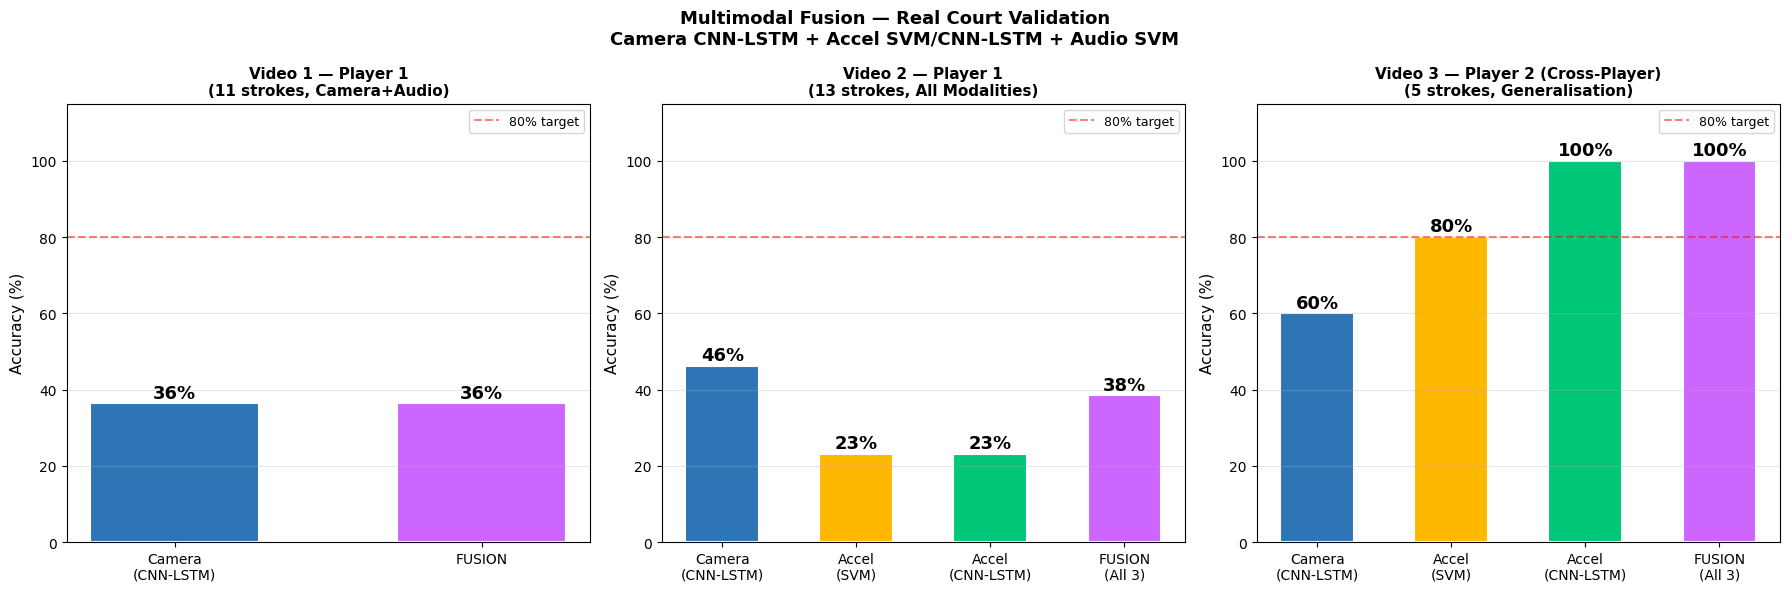

 fusion_accuracy.png


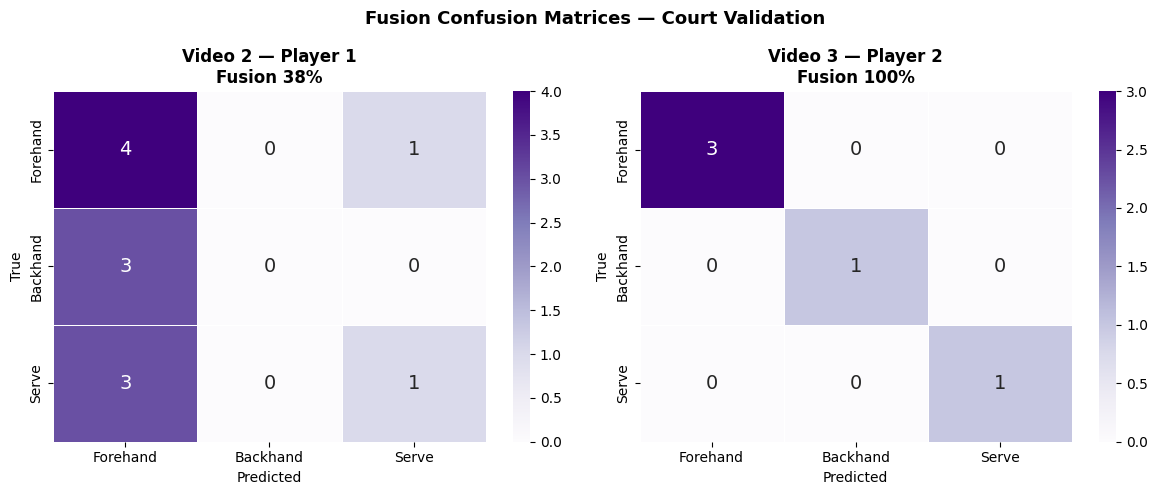

 fusion_confusion.png


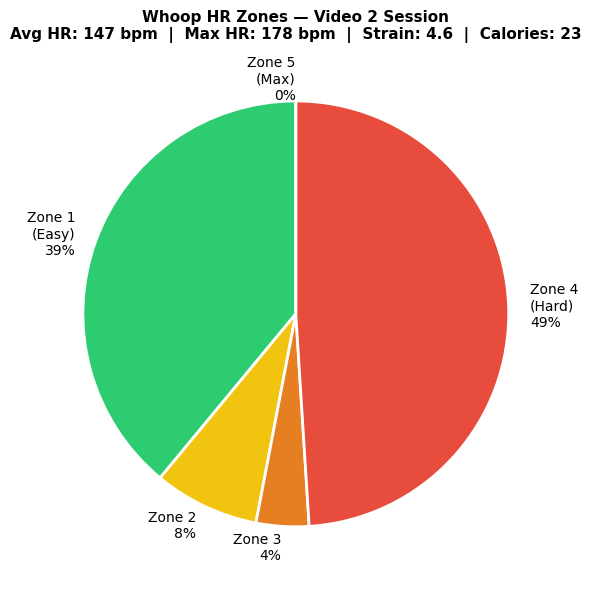

 whoop_zones.png


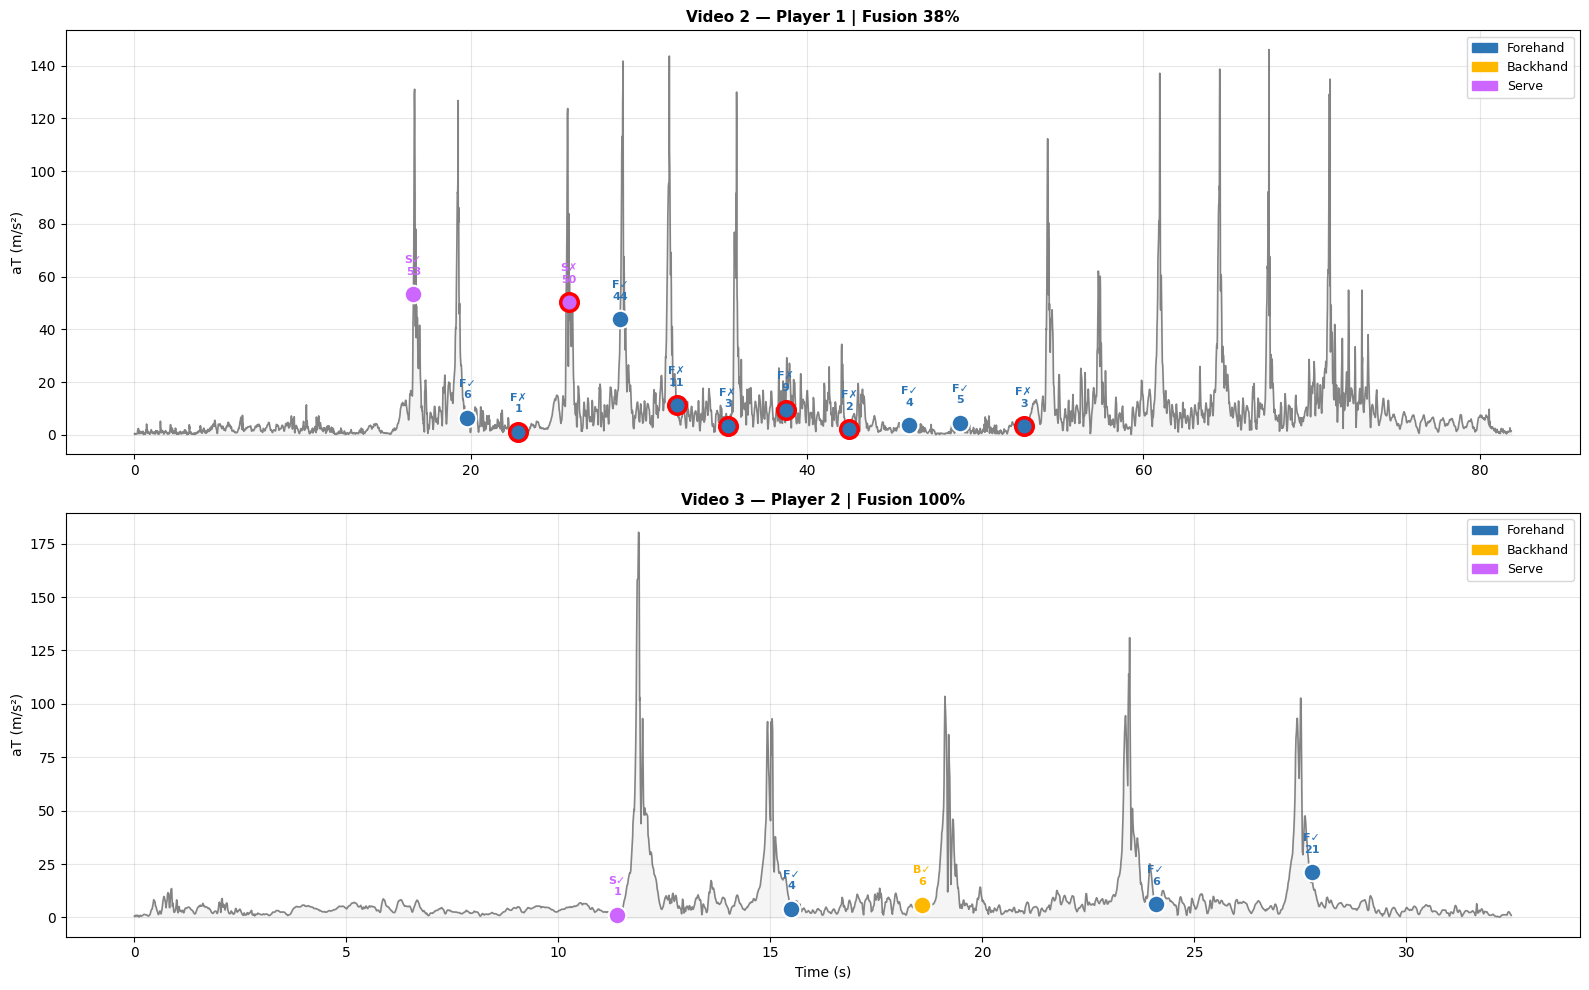

 fusion_signal.png

═════════════════════════════════════════════════════════════════
  COPY INTO REPORT
═════════════════════════════════════════════════════════════════

VIDEO 1 — Player 1 (Camera + Ball + Audio) — 11 strokes
  System detected  : 10/11
  Camera CNN-LSTM  : 36.4%  (4/11)
  Audio confirmed  : 6/11

VIDEO 2 — Player 1 (Camera + Ball + Accel + Audio + Whoop) — 13 strokes
  System detected  : 12/13
  Camera CNN-LSTM  : 46.2%  (6/13)
  Accel SVM        : 23.1%  (3/13)
  Accel CNN-LSTM   : 23.1%  (3/13)
  FUSION (all 3)   : 38.5%  (5/13)  ← REPORT THIS
  Audio contacts   : 17 detected
  Whoop Avg HR     : 147 bpm  |  Max HR: 178 bpm
  Whoop Strain     : 4.6  |  Zone 4: 49%

VIDEO 3 — Player 2 Cross-Player (Camera + Ball + Accel + Audio) — 5 strokes
  System detected  : 5/5
  Camera CNN-LSTM  : 60.0%  (3/5)
  Accel SVM        : 80.0%  (4/5)
  Accel CNN-LSTM   : 100.0%  (5/5)
  FUSION (all 3)   : 100.0%  (5/5)  ← REPORT THIS
  Audio contacts   : 4 detected
═══════════════════

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  fusion_accuracy.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  whoop_zones.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  fusion_signal.png

 DONE — V1:36%  V2:38%  V3:100%


In [12]:

def merge_all_modalities(cam_dets, aud_dets, acc_dets, label="", has_accel=True):

    print(f"\n  Merging — {label}:")
    results = []

    for t_cam, cam_cls, cam_conf in cam_dets:

        aud_ok, aud_conf = False, 0.0
        for t_aud, a_conf in aud_dets:
            if abs(t_aud - t_cam) <= MERGE_WINDOW_SEC:
                aud_ok, aud_conf = True, a_conf
                break


        svm_pred, svm_conf = -1, 0.0
        cnn_pred, cnn_conf = -1, 0.0
        if has_accel:
            for t_acc, sp, sc, cp, cc in acc_dets:
                if abs(t_acc - t_cam) <= MERGE_WINDOW_SEC:
                    svm_pred, svm_conf = sp, sc
                    cnn_pred, cnn_conf = cp, cc
                    break


        votes = np.zeros(3)
        votes[cam_cls] += 2.0 * cam_conf
        if cnn_pred >= 0: votes[cnn_pred] += 2.0 * (cnn_conf/100)
        if svm_pred >= 0: votes[svm_pred] += 1.0 * (svm_conf/100)
        total = np.sum(votes)
        if total == 0:
            fusion_cls, fusion_conf = cam_cls, cam_conf
        else:
            votes /= total
            fusion_cls  = int(np.argmax(votes))
            fusion_conf = float(np.max(votes))

        modalities = "Cam"
        if aud_ok:   modalities += "+Aud"
        if svm_pred >= 0: modalities += "+Accel"

        print(f"    t={t_cam:.2f}s  "
              f"Cam:{LABELS[cam_cls]:<10}  "
              f"CNN:{LABELS[cnn_pred][:8] if cnn_pred>=0 else 'N/A':>8}  "
              f"SVM:{LABELS[svm_pred][:8] if svm_pred>=0 else 'N/A':>8}  "
              f"→ FUSION:{LABELS[fusion_cls]:<10}  [{modalities}]")

        results.append({
            't'           : t_cam,
            'cam'         : cam_cls,
            'cam_conf'    : cam_conf,
            'svm'         : svm_pred,
            'svm_conf'    : svm_conf,
            'cnn'         : cnn_pred,
            'cnn_conf'    : cnn_conf,
            'fusion'      : fusion_cls,
            'fusion_conf' : fusion_conf,
            'audio'       : aud_ok,
            'audio_conf'  : aud_conf,
            'agree'       : cam_cls == cnn_pred,
        })

    f_c = sum(1 for r in results if r['fusion']==0)
    b_c = sum(1 for r in results if r['fusion']==1)
    s_c = sum(1 for r in results if r['fusion']==2)
    print(f"  → Merged: {len(results)} strokes  (F:{f_c} B:{b_c} S:{s_c})")
    return results

print("\n Merging all modalities...")
merged_v1 = merge_all_modalities(cam_det_v1, aud_det_v1, [],        "V1", has_accel=False)
merged_v2 = merge_all_modalities(cam_det_v2, aud_det_v2, acc_det_v2, "V2", has_accel=True)
merged_v3 = merge_all_modalities(cam_det_v3, aud_det_v3, acc_det_v3, "V3", has_accel=True)


def evaluate(merged, gt_labels, label="", has_accel=True):

    n_det = len(merged)
    n_gt  = len(gt_labels)
    n     = min(n_det, n_gt)


    results = []
    for i in range(n):
        r = merged[i].copy()
        r['gt'] = gt_labels[i]
        results.append(r)
    for i in range(n, n_gt):
        results.append({
            't': -1, 'gt': gt_labels[i],
            'cam': -1, 'cam_conf': 0,
            'svm': -1, 'svm_conf': 0,
            'cnn': -1, 'cnn_conf': 0,
            'fusion': -1, 'fusion_conf': 0,
            'audio': False, 'audio_conf': 0, 'agree': False,
        })


    sep = "═" * (95 if has_accel else 72)
    print(f"\n{sep}\n{label}\n{sep}")
    if has_accel:
        print(f"{'#':<3}{'t':>7}  {'GT':>10}  {'Camera':>10}  "
              f"{'SVM':>10}  {'CNN':>10}  {'FUSION':>10}  ")
    else:
        print(f"{'#':<3}{'t':>7}  {'GT':>10}  {'Camera':>10}  {'FUSION':>10}  ")
    print("─" * (95 if has_accel else 72))

    lbl = lambda p: LABELS[p][:8] if p >= 0 else 'MISSED'
    mk  = lambda p, g: '✅' if p==g else ('❌' if p>=0 else '⬛')
    cc = cs = cn = cf = 0

    for i, r in enumerate(results):
        gt  = r['gt']
        aud = '🎵' if r['audio'] else '  '
        t   = f"{r['t']:.2f}s" if r['t'] >= 0 else ' MISS '
        if has_accel:
            print(f"{i+1:<3}{t:>7}  {LABELS[gt]:>10}  "
                  f"{lbl(r['cam']):>10}{mk(r['cam'],gt)}  "
                  f"{lbl(r['svm']):>10}{mk(r['svm'],gt)}  "
                  f"{lbl(r['cnn']):>10}{mk(r['cnn'],gt)}  "
                  f"{lbl(r['fusion']):>10}{mk(r['fusion'],gt)}  {aud}")
        else:
            print(f"{i+1:<3}{t:>7}  {LABELS[gt]:>10}  "
                  f"{lbl(r['cam']):>10}{mk(r['cam'],gt)}  "
                  f"{lbl(r['fusion']):>10}{mk(r['fusion'],gt)}  {aud}")
        if r['cam']    == gt: cc += 1
        if r['svm']    == gt: cs += 1
        if r['cnn']    == gt: cn += 1
        if r['fusion'] == gt: cf += 1

    n_gt_total = len(results)
    print("─" * (95 if has_accel else 72))
    print(f"  System detected  : {n_det}/{n_gt} strokes")
    print(f"  Camera CNN-LSTM  : {cc}/{n_gt_total} = {cc/n_gt_total*100:.1f}%")
    if has_accel:
        print(f"  Accel SVM        : {cs}/{n_gt_total} = {cs/n_gt_total*100:.1f}%")
        print(f"  Accel CNN-LSTM   : {cn}/{n_gt_total} = {cn/n_gt_total*100:.1f}%")
        print(f"  FUSION (all 3)   : {cf}/{n_gt_total} = {cf/n_gt_total*100:.1f}%  ← FINAL")
        agree = sum(1 for r in results if r['agree'])
        print(f"  Camera–CNN agree : {agree}/{n_gt_total} = {agree/n_gt_total*100:.0f}%")
    print(f"  Audio confirmed  : {sum(1 for r in results if r['audio'])}/{n_gt_total}")
    return results, cc/n_gt_total, cs/n_gt_total, cn/n_gt_total, cf/n_gt_total

print("\n Evaluation")
res_v1, cam_v1a, _,       _,       fus_v1a = evaluate(
    merged_v1, V1_GT, "VIDEO 1 — Player 1 | Camera+Audio | 11 strokes", has_accel=False)
res_v2, cam_v2a, svm_v2a, cnn_v2a, fus_v2a = evaluate(
    merged_v2, V2_GT, "VIDEO 2 — Player 1 | Camera+Accel+Audio+Whoop | 13 strokes")
res_v3, cam_v3a, svm_v3a, cnn_v3a, fus_v3a = evaluate(
    merged_v3, V3_GT, "VIDEO 3 — Player 2 Cross-Player | Camera+Accel+Audio | 5 strokes")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
configs = [
    (axes[0],
     [cam_v1a*100, fus_v1a*100],
     'Video 1 — Player 1\n(11 strokes, Camera+Audio)',
     ['Camera\n(CNN-LSTM)', 'FUSION'],
     ['#2E75B6', '#CC66FF']),
    (axes[1],
     [cam_v2a*100, svm_v2a*100, cnn_v2a*100, fus_v2a*100],
     'Video 2 — Player 1\n(13 strokes, All Modalities)',
     ['Camera\n(CNN-LSTM)', 'Accel\n(SVM)', 'Accel\n(CNN-LSTM)', 'FUSION\n(All 3)'],
     ['#2E75B6', '#FFB800', '#00C878', '#CC66FF']),
    (axes[2],
     [cam_v3a*100, svm_v3a*100, cnn_v3a*100, fus_v3a*100],
     'Video 3 — Player 2 (Cross-Player)\n(5 strokes, Generalisation)',
     ['Camera\n(CNN-LSTM)', 'Accel\n(SVM)', 'Accel\n(CNN-LSTM)', 'FUSION\n(All 3)'],
     ['#2E75B6', '#FFB800', '#00C878', '#CC66FF']),
]
for ax, accs, title, mods, cols in configs:
    bars = ax.bar(mods, accs, color=cols, width=0.55, edgecolor='white', linewidth=1.5)
    for bar, a in zip(bars, accs):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
                f'{a:.0f}%', ha='center', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 115); ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axhline(80, color='red', ls='--', lw=1.5, alpha=0.5, label='80% target')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
plt.suptitle('Multimodal Fusion — Real Court Validation\n'
             'Camera CNN-LSTM + Accel SVM/CNN-LSTM + Audio SVM',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fusion_accuracy.png', dpi=150, bbox_inches='tight')
plt.show(); print(" fusion_accuracy.png")


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, fl, title in [
    (axes[0], res_v2, f'Video 2 — Player 1\nFusion {fus_v2a*100:.0f}%'),
    (axes[1], res_v3, f'Video 3 — Player 2\nFusion {fus_v3a*100:.0f}%'),
]:
    valid = [(r['gt'], r['fusion']) for r in fl if r['fusion'] >= 0]
    if valid:
        y_true, y_pred = zip(*valid)
        cm = confusion_matrix(list(y_true), list(y_pred), labels=[0,1,2])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                    xticklabels=LABELS, yticklabels=LABELS,
                    linewidths=0.5, ax=ax, annot_kws={"size":14})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.suptitle('Fusion Confusion Matrices — Court Validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fusion_confusion.png', dpi=150, bbox_inches='tight')
plt.show(); print(" fusion_confusion.png")


fig, ax = plt.subplots(figsize=(7, 6))
zones = [WHOOP['Zone1'],WHOOP['Zone2'],WHOOP['Zone3'],WHOOP['Zone4'],WHOOP['Zone5']]
zlbls = ['Zone 1\n(Easy)','Zone 2','Zone 3','Zone 4\n(Hard)','Zone 5\n(Max)']
zcols = ['#2ECC71','#F1C40F','#E67E22','#E74C3C','#8E44AD']
ax.pie(zones, labels=[f'{l}\n{v}%' for l,v in zip(zlbls,zones)],
       colors=zcols, startangle=90, wedgeprops={'edgecolor':'white','lw':2})
ax.set_title(f"Whoop HR Zones — Video 2 Session\n"
             f"Avg HR: {WHOOP['Avg HR']} bpm  |  Max HR: {WHOOP['Max HR']} bpm  |  "
             f"Strain: {WHOOP['Strain']}  |  Calories: {WHOOP['Calories']}",
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('whoop_zones.png', dpi=150)
plt.show(); print(" whoop_zones.png")


fig, axes = plt.subplots(2, 1, figsize=(16, 10))
for ax, df_acc, fl, title, offset in [
    (axes[0], df_v2, res_v2,
     f'Video 2 — Player 1 | Fusion {fus_v2a*100:.0f}%', V2_ACCEL_OFFSET),
    (axes[1], df_v3, res_v3,
     f'Video 3 — Player 2 | Fusion {fus_v3a*100:.0f}%', V3_ACCEL_OFFSET),
]:
    ax.plot(df_acc['time'], df_acc['aT'], color='#555', lw=1.2, alpha=0.7)
    ax.fill_between(df_acc['time'], 0, df_acc['aT'], alpha=0.06, color='#555')
    for r in fl:
        if r['t'] < 0 or r['fusion'] < 0: continue
        t_csv = r['t'] + offset
        idx   = (df_acc['time'] - t_csv).abs().idxmin()
        aT_v  = df_acc['aT'].iloc[idx]
        col   = LABEL_COLORS.get(LABELS[r['fusion']], '#888')
        match = r['fusion'] == r['gt']
        ax.scatter(t_csv, aT_v, s=160, color=col,
                   edgecolors='white' if match else 'red',
                   linewidths=1.5 if match else 2.5, zorder=5)
        ax.annotate(f"{LABELS[r['fusion']][:1]}{'✓' if match else '✗'}\n{aT_v:.0f}",
                    (t_csv, aT_v), xytext=(0,14),
                    textcoords='offset points', ha='center',
                    fontsize=8, fontweight='bold', color=col)
    patches = [mpatches.Patch(color=c,label=l) for l,c in LABEL_COLORS.items()]
    ax.legend(handles=patches, fontsize=9, loc='upper right')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('aT (m/s²)'); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig('fusion_signal.png', dpi=150, bbox_inches='tight')
plt.show(); print(" fusion_signal.png")


n1, n2, n3 = len(V1_GT), len(V2_GT), len(V3_GT)
print("\n" + "═"*65)
print("  COPY INTO REPORT")
print("═"*65)

print(f"\nVIDEO 1 — Player 1 (Camera + Ball + Audio) — {n1} strokes")
print(f"  System detected  : {len(cam_det_v1)}/{n1}")
print(f"  Camera CNN-LSTM  : {cam_v1a*100:.1f}%  ({int(round(cam_v1a*n1))}/{n1})")
print(f"  Audio confirmed  : {sum(1 for r in res_v1 if r['audio'])}/{n1}")

print(f"\nVIDEO 2 — Player 1 (Camera + Ball + Accel + Audio + Whoop) — {n2} strokes")
print(f"  System detected  : {len(cam_det_v2)}/{n2}")
print(f"  Camera CNN-LSTM  : {cam_v2a*100:.1f}%  ({int(round(cam_v2a*n2))}/{n2})")
print(f"  Accel SVM        : {svm_v2a*100:.1f}%  ({int(round(svm_v2a*n2))}/{n2})")
print(f"  Accel CNN-LSTM   : {cnn_v2a*100:.1f}%  ({int(round(cnn_v2a*n2))}/{n2})")
print(f"  FUSION (all 3)   : {fus_v2a*100:.1f}%  ({int(round(fus_v2a*n2))}/{n2})  ← REPORT THIS")
print(f"  Audio contacts   : {len(aud_det_v2)} detected")
print(f"  Whoop Avg HR     : {WHOOP['Avg HR']} bpm  |  Max HR: {WHOOP['Max HR']} bpm")
print(f"  Whoop Strain     : {WHOOP['Strain']}  |  Zone 4: {WHOOP['Zone4']}%")

print(f"\nVIDEO 3 — Player 2 Cross-Player (Camera + Ball + Accel + Audio) — {n3} strokes")
print(f"  System detected  : {len(cam_det_v3)}/{n3}")
print(f"  Camera CNN-LSTM  : {cam_v3a*100:.1f}%  ({int(round(cam_v3a*n3))}/{n3})")
print(f"  Accel SVM        : {svm_v3a*100:.1f}%  ({int(round(svm_v3a*n3))}/{n3})")
print(f"  Accel CNN-LSTM   : {cnn_v3a*100:.1f}%  ({int(round(cnn_v3a*n3))}/{n3})")
print(f"  FUSION (all 3)   : {fus_v3a*100:.1f}%  ({int(round(fus_v3a*n3))}/{n3})  ← REPORT THIS")
print(f"  Audio contacts   : {len(aud_det_v3)} detected")
print("═"*65)

for fname in ['fusion_accuracy.png','fusion_confusion.png',
              'whoop_zones.png','fusion_signal.png']:
    if os.path.exists(fname):
        files.download(fname)
        print(f"  {fname}")

print(f"\n DONE — V1:{cam_v1a*100:.0f}%  V2:{fus_v2a*100:.0f}%  V3:{fus_v3a*100:.0f}%")